# **Lab 09**

**Problem.** Load the popular Iris/Titanic dataset. After that, draw various diagrams (line plot,
scatter plot, bars, histograms, pie charts, and subplots) that can be applied to the attributes of the
loaded dataset.

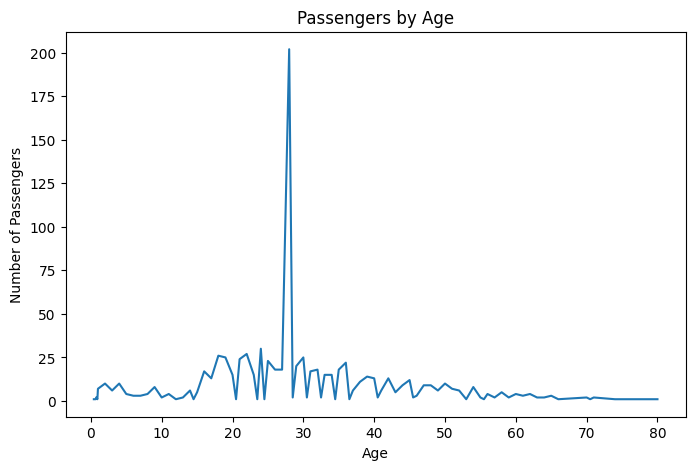

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Fare"] = pd.to_numeric(df["Fare"], errors="coerce")

df.loc[(df["Age"] < 0) | (df["Age"] > 100), "Age"] = df["Age"].median()

df.drop_duplicates(inplace=True)

# For line plot
age_count = df["Age"].dropna().value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(age_count.index, age_count.values)

plt.title("Passengers by Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

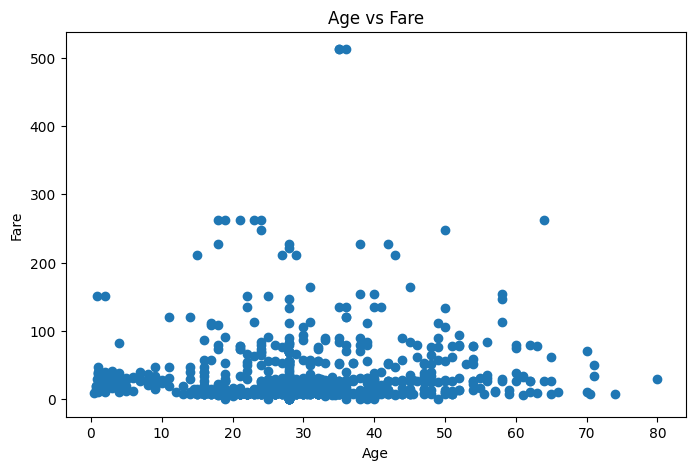

In [4]:
# For scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

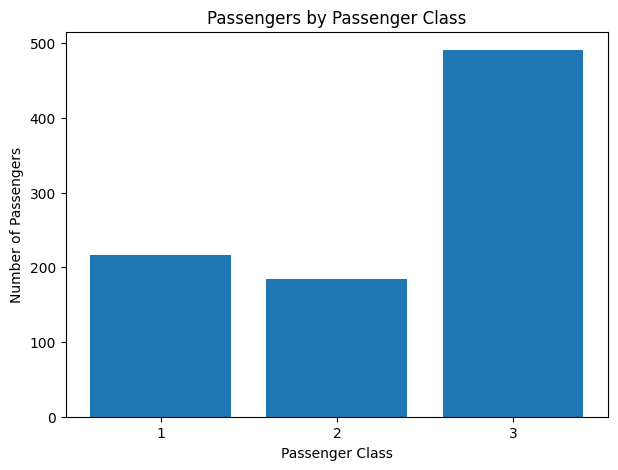

In [5]:
# For bar chart
class_count = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    class_count.index.astype(str),
    class_count.values
)

plt.title("Passengers by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

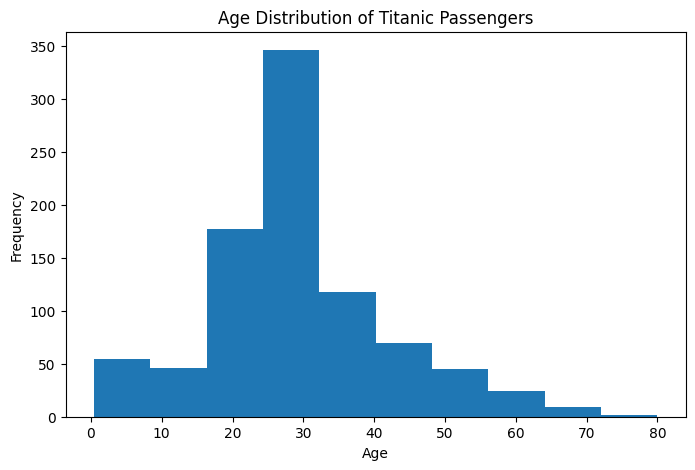

In [6]:
# For histogram
plt.figure(figsize=(8, 5))

plt.hist(df["Age"].dropna(), bins=10)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

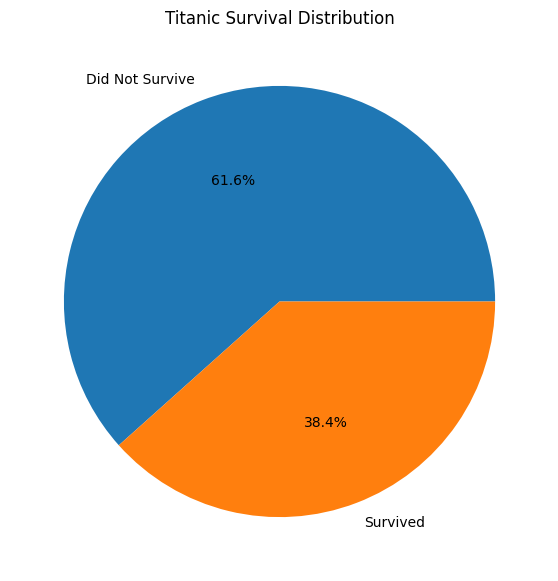

In [7]:
# For pie chart
survival_count = df["Survived"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    survival_count.values,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%"
)

plt.title("Titanic Survival Distribution")
plt.show()

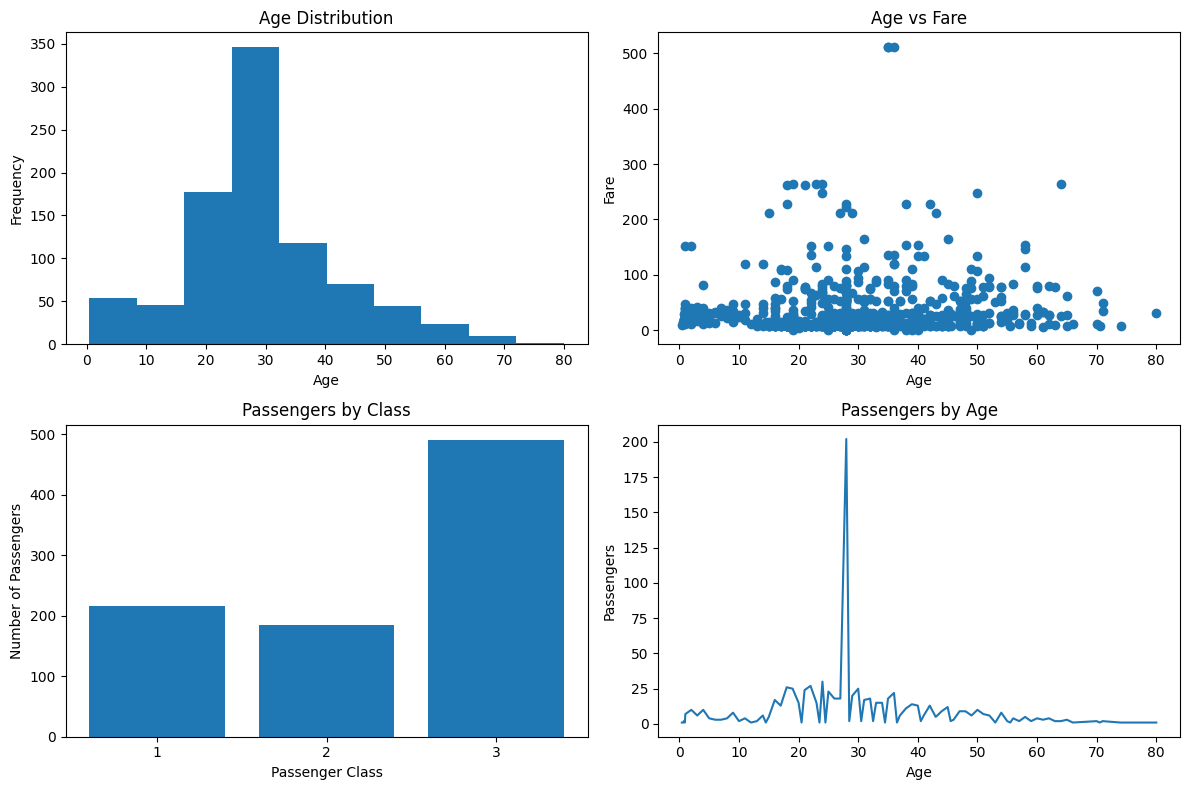

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram
axes[0, 0].hist(df["Age"].dropna(), bins=10)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

# Scatter plot
axes[0, 1].scatter(df["Age"], df["Fare"])
axes[0, 1].set_title("Age vs Fare")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Fare")

# Bar chart
class_count = df["Pclass"].value_counts().sort_index()
axes[1, 0].bar(
    class_count.index.astype(str),
    class_count.values
)
axes[1, 0].set_title("Passengers by Class")
axes[1, 0].set_xlabel("Passenger Class")
axes[1, 0].set_ylabel("Number of Passengers")

# Line plot
age_count = df["Age"].dropna().value_counts().sort_index()
axes[1, 1].plot(age_count.index, age_count.values)
axes[1, 1].set_title("Passengers by Age")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Passengers")

plt.tight_layout()
plt.show()